# Imputation Shootout: Which Strategy Survives Missing Data?

Coursework from **Applied Unsupervised Learning in Python** (University of Michigan, More Applied Data Science with Python). Both notebooks run end to end with outputs.

We take 100 apple quality records, erase 70 percent of the feature cells at random, and ask which imputation strategy keeps a regressor useful. Three strategies face off against a full data baseline, all scored with 7 fold cross validation R² and a RandomForestRegressor.

In [1]:
import matplotlib
matplotlib.use("Agg")  # headless backend so figures render without a screen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

class Image:
    """Minimal stand in for IPython display Image: embeds a PNG file."""
    def __init__(self, path):
        self.path = path
    def _repr_png_(self):
        with open(self.path, "rb") as f:
            return f.read()
    def __repr__(self):
        return f"<chart PNG: {self.path}>"

## Load the apple quality data

In [2]:
apple = pd.read_csv("../data/apple_quality.csv").head(100)
print("rows:", len(apple))
print("target classes:", apple["Quality"].value_counts().to_dict())
apple.head()

rows: 100
target classes: {'good': 55, 'bad': 45}


,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


## Punch holes: 70 percent of cells go missing at random

In [3]:
def create_copy_with_missing_values(X, y, missing_rate=0.70):
    n_samples, n_features = X.shape
    n_missing = int(n_samples * missing_rate)
    rng = np.random.RandomState(42)
    rows = rng.choice(n_samples, size=n_missing, replace=False)
    cols = rng.randint(0, n_features, n_missing)
    X_missing = X.copy()
    X_missing[rows, cols] = np.nan
    return X_missing, y.copy()

X_full = apple.drop(columns=["Quality", "A_id"]).values.astype(np.float64)
y_full = np.array([1 if q == "good" else 0 for q in apple["Quality"].values])
X_missing, y_missing = create_copy_with_missing_values(X_full, y_full)
print("NaN cells:", int(np.isnan(X_missing).sum()))
print("rows touched:", int(np.isnan(X_missing).any(axis=1).sum()), "of", len(X_missing))

NaN cells: 70
rows touched: 70 of 100


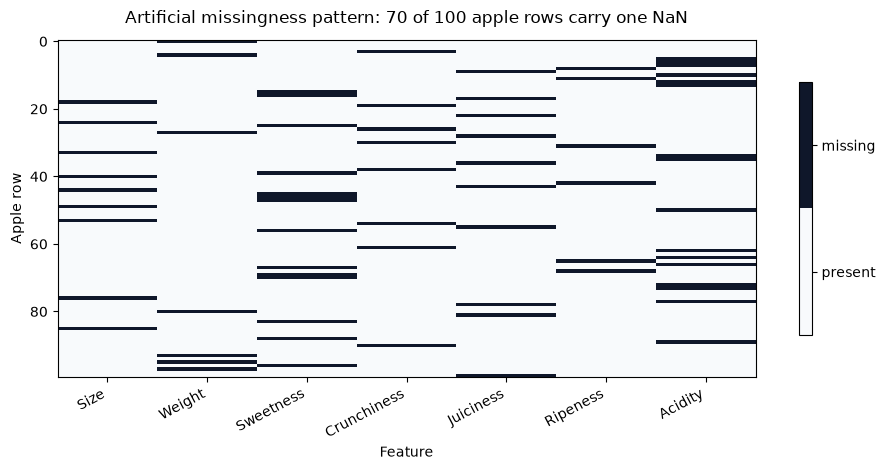

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
cmap = matplotlib.colors.ListedColormap(["#F8FAFC", "#0F172A"])
im = ax.imshow(np.isnan(X_missing).astype(int), aspect="auto", cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(7))
ax.set_xticklabels(["Size", "Weight", "Sweetness", "Crunchiness", "Juiciness", "Ripeness", "Acidity"], rotation=28, ha="right")
ax.set_xlabel("Feature")
ax.set_ylabel("Apple row")
ax.set_title("Artificial missingness pattern: 70 of 100 apple rows carry one NaN", pad=12)
cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75], shrink=0.75)
cbar.ax.set_yticklabels(["present", "missing"])
fig.tight_layout()
fig.savefig("../charts/chart_missingness.png", bbox_inches="tight")
plt.close(fig)
Image("../charts/chart_missingness.png")

## Strategy A: fill every hole with zero, plus a missingness indicator

In [5]:
def get_scores(imputer):
    pipe = make_pipeline(imputer, RandomForestRegressor(random_state=42))
    return cross_val_score(pipe, X_missing, y_missing, scoring="r2", cv=7)

s_a = get_scores(SimpleImputer(strategy="constant", fill_value=0, add_indicator=True))
print(f"Strategy A mean R\u00b2: {s_a.mean():.4f}  std: {s_a.std():.4f}")

Strategy A mean R²: 0.1487  std: 0.1904


## Strategy B: drop every row that contains a hole

In [6]:
keep = ~np.isnan(X_missing).any(axis=1)
print("rows kept:", int(keep.sum()), "of", len(keep))
s_b = cross_val_score(RandomForestRegressor(random_state=42),
                      X_missing[keep], y_missing[keep], scoring="r2", cv=7)
print(f"Strategy B mean R\u00b2: {s_b.mean():.4f}  std: {s_b.std():.4f}")

rows kept: 30 of 100
Strategy B mean R²: 0.1548  std: 0.3114


## Strategy C: kNN imputation, plus a missingness indicator

In [7]:
s_c = get_scores(KNNImputer(add_indicator=True))
print(f"Strategy C mean R\u00b2: {s_c.mean():.4f}  std: {s_c.std():.4f}")

Strategy C mean R²: 0.2222  std: 0.1233


## Full data baseline and the final scoreboard

In [8]:
s_full = cross_val_score(RandomForestRegressor(random_state=42), X_full, y_full, scoring="r2", cv=7)
print(f"Full data mean R\u00b2: {s_full.mean():.4f}  std: {s_full.std():.4f}")

Full data mean R²: 0.2882  std: 0.1886


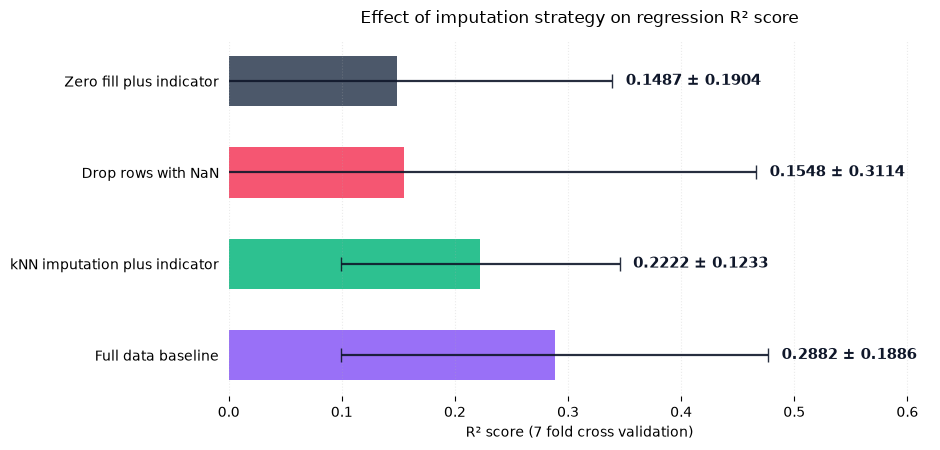

In [9]:
labels = ["Zero fill plus indicator", "Drop rows with NaN",
          "kNN imputation plus indicator", "Full data baseline"]
means = np.array([s_a.mean(), s_b.mean(), s_c.mean(), s_full.mean()])
stds = np.array([s_a.std(), s_b.std(), s_c.std(), s_full.std()])
colors = ["#334155", "#F43F5E", "#10B981", "#8B5CF6"]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(labels))
ax.barh(y, means, xerr=stds, color=colors, alpha=0.88, height=0.55,
        error_kw={"ecolor": "#0F172A", "elinewidth": 1.6, "capsize": 5, "alpha": 0.9})
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.012, i, f"{m:.4f} \u00b1 {s:.4f}", va="center",
            fontsize=10.5, fontweight="bold", color="#0F172A")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("R\u00b2 score (7 fold cross validation)")
ax.set_title("Effect of imputation strategy on regression R\u00b2 score", pad=12)
ax.set_xlim(0, 0.62)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25, linestyle=":")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig("../charts/chart_imputation_r2.png", bbox_inches="tight")
plt.close(fig)
Image("../charts/chart_imputation_r2.png")

## Takeaway

kNN imputation wins the shootout at 0.2222, clearly ahead of zero fill (0.1487) and row dropping (0.1548). Dropping rows throws away 70 of the 100 apples, which explains the wild standard deviation of 0.3114: every fold trains on a tiny, different sample. The full data baseline of 0.2882 shows how much signal the holes destroy, yet smart imputation recovers most of it. Lesson: borrow information from neighbors instead of deleting data.